## Imports and Setup

In [18]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
import xgboost as xgb

from src import (
    RewardModelEnsemble, RewardModelSingle,
    FeaturePipeline, load_and_prepare,
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT,
    seed_everything, setup_plotting, timer, save_results,
    TREATMENT_COLORS, ensure_dirs,
)
from src.utils import plot_feature_importance, plot_predicted_vs_actual, plot_training_loss

seed_everything(42)
setup_plotting()
ensure_dirs()
print("Setup complete")

Setup complete


## Load Data and Create Train/Test Split

In [19]:
df = pd.read_csv("../data/bandit_dataset.csv")
print(f"Loaded {len(df)} rows")

# Unscaled pipeline for XGBoost (tree-based models don't need scaling)
pipe_unscaled = FeaturePipeline(scale=False, add_interactions=True)
X_train, X_test, meta = pipe_unscaled.fit_transform_split(df, test_size=0.2, seed=42)
pipe_unscaled.save("../models/feature_pipeline_unscaled.joblib")

# Scaled pipeline for neural models
pipe_scaled = FeaturePipeline(scale=True, add_interactions=True)
X_train_s, X_test_s, meta_s = pipe_scaled.fit_transform_split(df, test_size=0.2, seed=42)
pipe_scaled.save("../models/feature_pipeline_scaled.joblib")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {len(meta['feature_names'])}")
print(f"Pipelines saved ✓")

X_train: (16000, 25)
X_test:  (4000, 25)
Features: 25
Pipelines saved ✓


## Inspect Train/Test Balance

In [20]:
print("── Train Set ──")
print(f"  Actions: {np.bincount(meta['a_train'], minlength=N_TREATMENTS)}")
print(f"  Mean reward: {meta['y_train'].mean():.3f}")

print("\n── Test Set ──")
print(f"  Actions: {np.bincount(meta['a_test'], minlength=N_TREATMENTS)}")
print(f"  Mean reward: {meta['y_test'].mean():.3f}")

print("\nPer-treatment train sample sizes:")
for k in range(N_TREATMENTS):
    n_k = (meta['a_train'] == k).sum()
    print(f"  {IDX_TO_TREATMENT[k]:<12} n={n_k:>5}")

── Train Set ──
  Actions: [5259 3250 2879 1754 2858]
  Mean reward: 3.836

── Test Set ──
  Actions: [1315  813  720  438  714]
  Mean reward: 3.801

Per-treatment train sample sizes:
  Metformin    n= 5259
  GLP-1        n= 3250
  SGLT-2       n= 2879
  DPP-4        n= 1754
  Insulin      n= 2858


## Train Ensemble Reward Model (One XGBoost per Treatment)

In [21]:

print("=" * 60)
print("TRAINING: RewardModelEnsemble (5 separate XGBoost models)")
print("=" * 60)

ensemble = RewardModelEnsemble(xgb_params={
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "n_jobs": -1,
    "random_state": 42,
})

with timer("Ensemble training"):
    ensemble.fit(
        X_train, meta['a_train'], meta['y_train'],
        feature_names=meta['feature_names'],
        eval_X=X_test,
        eval_actions=meta['a_test'],
        eval_rewards=meta['y_test'],
    )

2026-03-13 07:12:28.860 | INFO     | src.utils:timer:437 - [TIMER] Ensemble training: 4.22s


## Evaluate Ensemble on Test Set

In [22]:
print("=" * 60)
print("EVALUATION: Ensemble Reward Model")
print("=" * 60)

eval_results = ensemble.evaluate(
    X_test,
    meta['a_test'],
    meta['y_test'],
    counterfactuals=meta.get('cf_test'),
    optimal_actions=meta.get('opt_test'),
)

for key, val in eval_results.items():
    if isinstance(val, dict):
        print(f"\n{key}:")
        for k, v in val.items():
            print(f"  {k:<15} {v}")
    else:
        print(f"{key:<25} {val}")

EVALUATION: Ensemble Reward Model

per_treatment_rmse:
  Metformin       0.3635
  GLP-1           0.4044
  SGLT-2          0.4179
  DPP-4           0.3427
  Insulin         0.517
overall_rmse              0.4107
policy_accuracy           0.9535
policy_value              6.0242
oracle_value              6.0344
regret                    0.0102


## Per-Treatment RMSE Breakdown

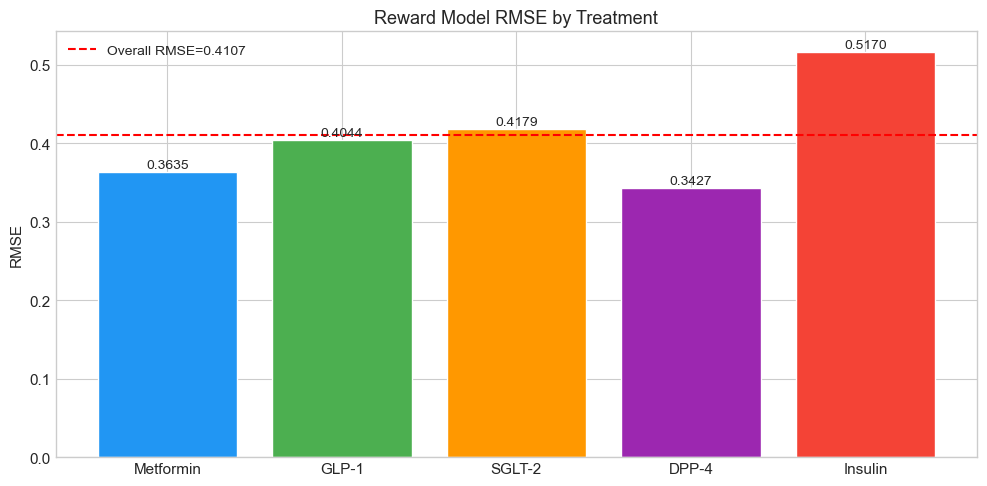

In [23]:

rmse_data = eval_results['per_treatment_rmse']
fig, ax = plt.subplots(figsize=(10, 5))

treatments = list(rmse_data.keys())
rmses = list(rmse_data.values())
colors = [TREATMENT_COLORS[t] for t in treatments]

bars = ax.bar(treatments, rmses, color=colors, edgecolor='white')
ax.set_ylabel("RMSE")
ax.set_title("Reward Model RMSE by Treatment")
ax.axhline(eval_results['overall_rmse'], color='red', linestyle='--',
           label=f"Overall RMSE={eval_results['overall_rmse']:.4f}")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

## Predicted vs Actual Scatter Plots

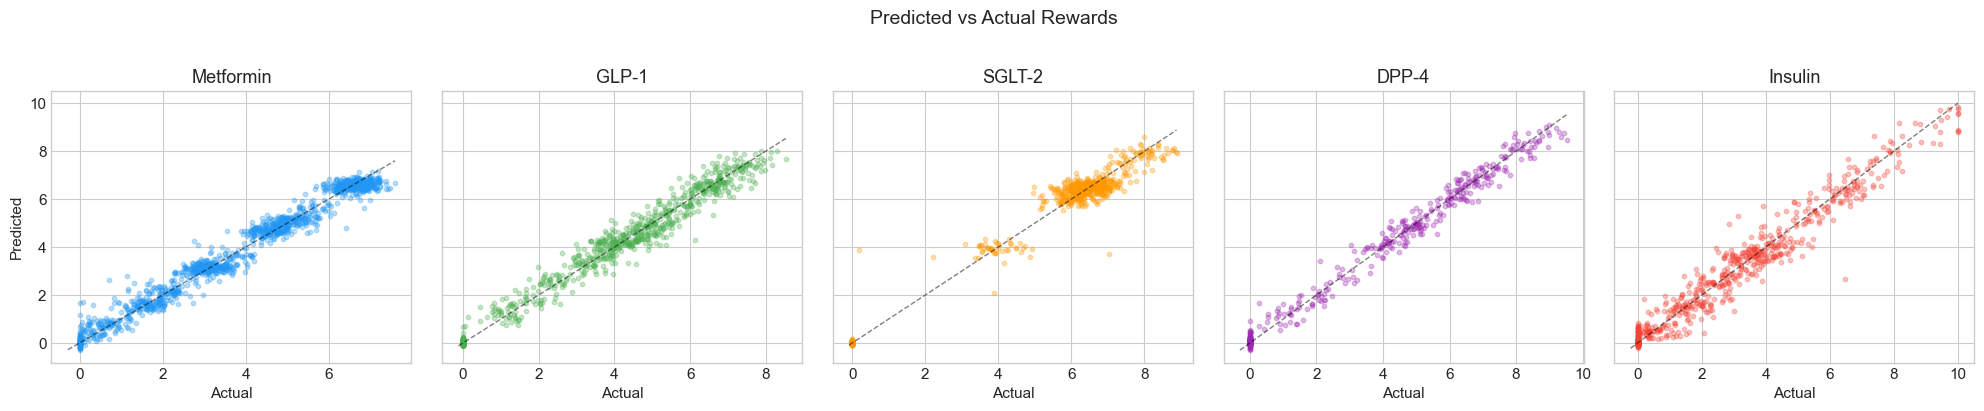

In [24]:
pred_all = ensemble.predict_all(X_test)

fig = plot_predicted_vs_actual(
    pred_all, meta['y_test'], meta['a_test'],
    save_path="../results/predicted_vs_actual_ensemble.png"
)
plt.show()

## Feature Importance Analysis

In [25]:
importances = ensemble.feature_importance(top_k=10)

fig = plot_feature_importance(
    importances, top_k=10,
    save_path="../results/feature_importance_ensemble.png"
)
plt.show()

# Print top 5 per treatment
print("\nTop 5 features per treatment:")
for treatment, feats in importances.items():
    print(f"\n  {treatment}:")
    for name, score in feats[:5]:
        print(f"    {name:<25} {score:.4f}")


Top 5 features per treatment:

  Metformin:
    duration_x_hba1c          0.2384
    diabetes_duration         0.2247
    bmi                       0.1601
    age                       0.1173
    c_peptide                 0.0914

  GLP-1:
    bmi                       0.3804
    bmi_x_nafld               0.2754
    nafld                     0.1640
    cvd                       0.0680
    cvd_x_egfr                0.0384

  SGLT-2:
    cvd                       0.3721
    ckd                       0.2949
    cvd_x_egfr                0.2571
    age_x_ckd                 0.0352
    renal_risk                0.0199

  DPP-4:
    age                       0.4125
    age_x_ckd                 0.2242
    ckd                       0.1384
    renal_risk                0.1127
    egfr                      0.0491

  Insulin:
    severity_score            0.5583
    c_peptide                 0.1845
    cpeptide_x_hba1c          0.0500
    hba1c_baseline            0.0462
    diabetes_duration   

## Policy Analysis — Greedy Actions from Reward Model

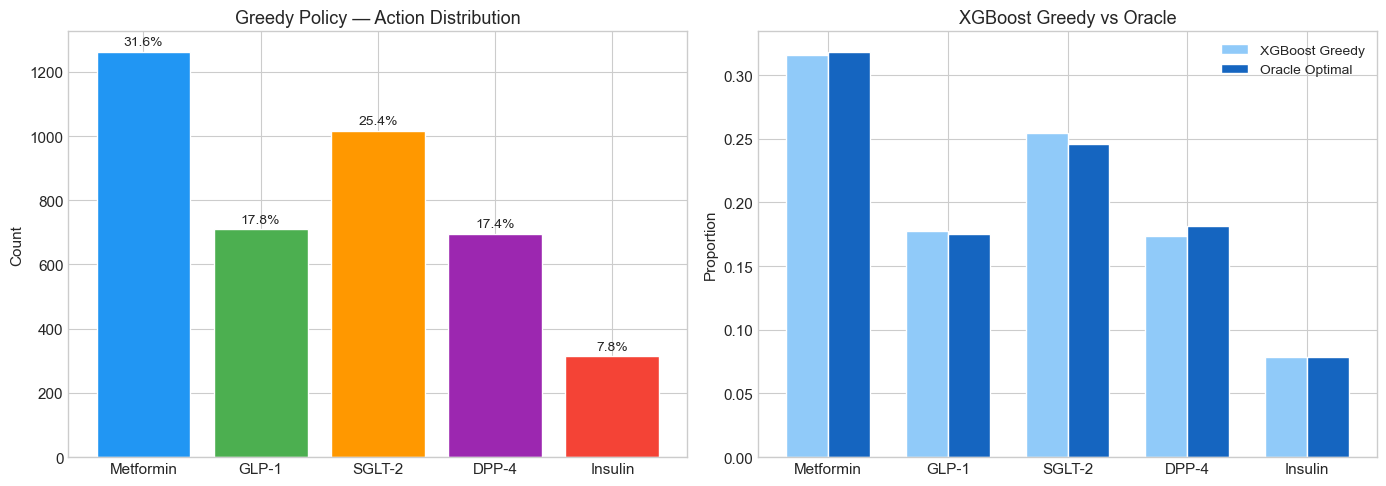

In [26]:
greedy_actions = ensemble.predict_best_action(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Greedy action distribution
greedy_counts = np.bincount(greedy_actions, minlength=N_TREATMENTS)
colors = [TREATMENT_COLORS[t] for t in TREATMENTS]
ax1.bar(TREATMENTS, greedy_counts, color=colors, edgecolor='white')
ax1.set_title("Greedy Policy — Action Distribution")
ax1.set_ylabel("Count")
for i, c in enumerate(greedy_counts):
    ax1.text(i, c + 20, f"{c/len(greedy_actions)*100:.1f}%", ha='center', fontsize=10)

# Compare with oracle optimal
if meta.get('opt_test') is not None:
    opt_counts = np.bincount(meta['opt_test'], minlength=N_TREATMENTS)
    x = np.arange(N_TREATMENTS)
    w = 0.35
    ax2.bar(x - w/2, greedy_counts / greedy_counts.sum(), w,
            label='XGBoost Greedy', color='#90CAF9', edgecolor='white')
    ax2.bar(x + w/2, opt_counts / opt_counts.sum(), w,
            label='Oracle Optimal', color='#1565C0', edgecolor='white')
    ax2.set_xticks(x)
    ax2.set_xticklabels(TREATMENTS)
    ax2.set_ylabel("Proportion")
    ax2.set_title("XGBoost Greedy vs Oracle")
    ax2.legend()

plt.tight_layout()
plt.show()

## Confusion Matrix — Greedy vs Oracle

In [27]:
if meta.get('opt_test') is not None:
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(meta['opt_test'], greedy_actions, labels=list(range(N_TREATMENTS)))
    cm_pct = cm / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=TREATMENTS, yticklabels=TREATMENTS)
    ax1.set_xlabel("Predicted (Greedy)")
    ax1.set_ylabel("Oracle Optimal")
    ax1.set_title("Confusion Matrix (Counts)")

    sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
                xticklabels=TREATMENTS, yticklabels=TREATMENTS)
    ax2.set_xlabel("Predicted (Greedy)")
    ax2.set_ylabel("Oracle Optimal")
    ax2.set_title("Confusion Matrix (Row-Normalized)")

    plt.tight_layout()
    plt.show()

    # Per-treatment accuracy
    print("Per-treatment accuracy (oracle → greedy match):")
    for k in range(N_TREATMENTS):
        mask = meta['opt_test'] == k
        if mask.sum() > 0:
            acc = (greedy_actions[mask] == k).mean()
            print(f"  {IDX_TO_TREATMENT[k]:<12} {acc:.4f} ({acc*100:.1f}%)")

Per-treatment accuracy (oracle → greedy match):
  Metformin    0.9662 (96.6%)
  GLP-1        0.9529 (95.3%)
  SGLT-2       0.9665 (96.6%)
  DPP-4        0.9188 (91.9%)
  Insulin      0.9429 (94.3%)


## Train Single Model (Alternative Approach)

In [28]:
print("=" * 60)
print("TRAINING: RewardModelSingle (one XGBoost, treatment as feature)")
print("=" * 60)

single = RewardModelSingle(xgb_params={
    "n_estimators": 800,
    "max_depth": 7,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "objective": "reg:squarederror",
    "n_jobs": -1,
    "random_state": 42,
})

with timer("Single model training"):
    single.fit(X_train, meta['a_train'], meta['y_train'])

# Evaluate
single_pred = single.predict_all(X_test)
single_greedy = single.predict_best_action(X_test)

if meta.get('cf_test') is not None and meta.get('opt_test') is not None:
    n_test = len(X_test)
    single_policy_value = meta['cf_test'][np.arange(n_test), single_greedy].mean()
    single_accuracy = (single_greedy == meta['opt_test']).mean()
    print(f"\nSingle Model Results:")
    print(f"  Policy value:  {single_policy_value:.4f}")
    print(f"  Accuracy:      {single_accuracy:.4f}")


Single Model Results:
  Policy value:  6.0154
  Accuracy:      0.9300


## Ensemble vs Single Model Comparison

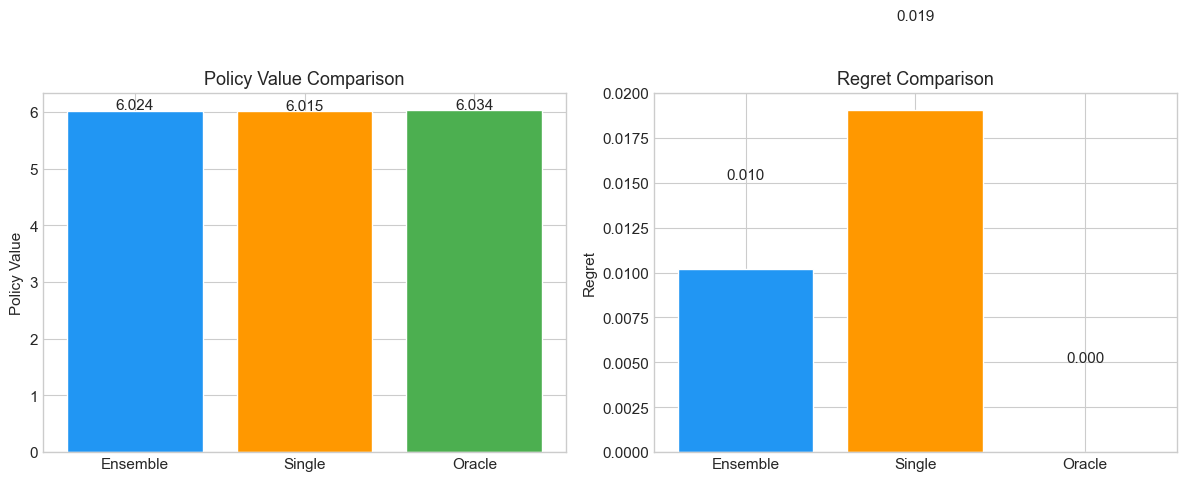

In [29]:
if meta.get('cf_test') is not None:
    n_test = len(X_test)

    ens_greedy = ensemble.predict_best_action(X_test)
    ens_value = meta['cf_test'][np.arange(n_test), ens_greedy].mean()
    ens_acc = (ens_greedy == meta['opt_test']).mean()

    sin_greedy = single.predict_best_action(X_test)
    sin_value = meta['cf_test'][np.arange(n_test), sin_greedy].mean()
    sin_acc = (sin_greedy == meta['opt_test']).mean()

    oracle_value = meta['cf_test'].max(axis=1).mean()

    comparison = pd.DataFrame([
        {"Model": "Ensemble (5 XGBoost)", "Policy Value": ens_value,
         "Regret": oracle_value - ens_value, "Accuracy": ens_acc},
        {"Model": "Single XGBoost", "Policy Value": sin_value,
         "Regret": oracle_value - sin_value, "Accuracy": sin_acc},
        {"Model": "Oracle", "Policy Value": oracle_value,
         "Regret": 0.0, "Accuracy": 1.0},
    ])
    print("\n" + "=" * 60)
    print("MODEL COMPARISON")
    print("=" * 60)
    print(comparison.to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    models = ["Ensemble", "Single", "Oracle"]
    values = [ens_value, sin_value, oracle_value]
    regrets = [oracle_value - ens_value, oracle_value - sin_value, 0]

    ax1.bar(models, values, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
    ax1.set_ylabel("Policy Value")
    ax1.set_title("Policy Value Comparison")
    for i, v in enumerate(values):
        ax1.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=11)

    ax2.bar(models, regrets, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
    ax2.set_ylabel("Regret")
    ax2.set_title("Regret Comparison")
    for i, r in enumerate(regrets):
        ax2.text(i, r + 0.005, f"{r:.3f}", ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()

## Hyperparameter Sensitivity — Max Depth

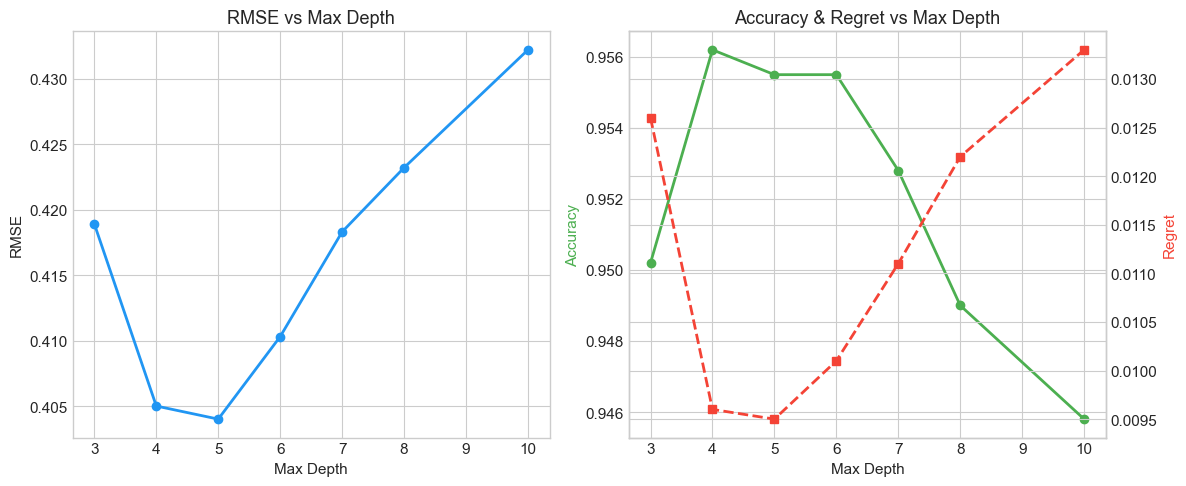

In [30]:
print("Hyperparameter sensitivity: max_depth")
depths = [3, 4, 5, 6, 7, 8, 10]
depth_results = []

for d in depths:
    model = RewardModelEnsemble(xgb_params={
        "n_estimators": 500,
        "max_depth": d,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "objective": "reg:squarederror",
        "n_jobs": -1,
        "random_state": 42,
    })
    model.fit(X_train, meta['a_train'], meta['y_train'], feature_names=meta['feature_names'])
    ev = model.evaluate(X_test, meta['a_test'], meta['y_test'],
                        counterfactuals=meta.get('cf_test'),
                        optimal_actions=meta.get('opt_test'))
    depth_results.append({
        "max_depth": d,
        "rmse": ev['overall_rmse'],
        "policy_value": ev.get('policy_value', np.nan),
        "accuracy": ev.get('policy_accuracy', np.nan),
        "regret": ev.get('regret', np.nan),
    })
    print(f"  depth={d}: rmse={ev['overall_rmse']:.4f}, "
          f"accuracy={ev.get('policy_accuracy', 'N/A')}, "
          f"regret={ev.get('regret', 'N/A')}")

depth_df = pd.DataFrame(depth_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(depth_df['max_depth'], depth_df['rmse'], 'o-', color='#2196F3', linewidth=2)
ax1.set_xlabel("Max Depth")
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE vs Max Depth")

ax2.plot(depth_df['max_depth'], depth_df['accuracy'], 'o-', color='#4CAF50', linewidth=2, label='Accuracy')
ax2r = ax2.twinx()
ax2r.plot(depth_df['max_depth'], depth_df['regret'], 's--', color='#F44336', linewidth=2, label='Regret')
ax2.set_xlabel("Max Depth")
ax2.set_ylabel("Accuracy", color='#4CAF50')
ax2r.set_ylabel("Regret", color='#F44336')
ax2.set_title("Accuracy & Regret vs Max Depth")

plt.tight_layout()
plt.show()

## Hyperparameter Sensitivity — Number of Estimators

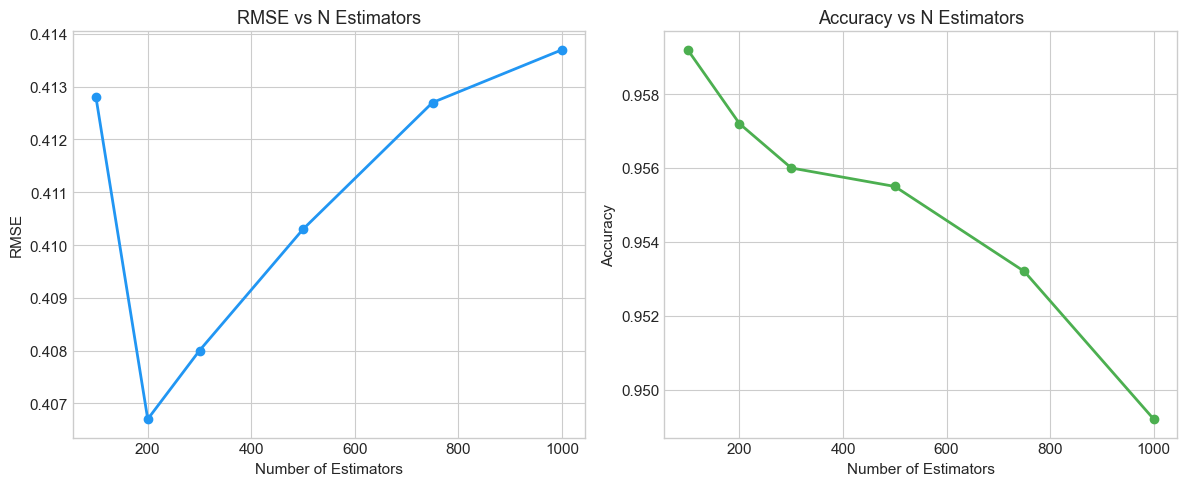

In [31]:
print("Hyperparameter sensitivity: n_estimators")
n_ests = [100, 200, 300, 500, 750, 1000]
nest_results = []

for n in n_ests:
    model = RewardModelEnsemble(xgb_params={
        "n_estimators": n,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "objective": "reg:squarederror",
        "n_jobs": -1,
        "random_state": 42,
    })
    model.fit(X_train, meta['a_train'], meta['y_train'], feature_names=meta['feature_names'])
    ev = model.evaluate(X_test, meta['a_test'], meta['y_test'],
                        counterfactuals=meta.get('cf_test'),
                        optimal_actions=meta.get('opt_test'))
    nest_results.append({
        "n_estimators": n,
        "rmse": ev['overall_rmse'],
        "accuracy": ev.get('policy_accuracy', np.nan),
        "regret": ev.get('regret', np.nan),
    })
    print(f"  n_estimators={n}: rmse={ev['overall_rmse']:.4f}, "
          f"accuracy={ev.get('policy_accuracy', 'N/A')}")

nest_df = pd.DataFrame(nest_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(nest_df['n_estimators'], nest_df['rmse'], 'o-', color='#2196F3', linewidth=2)
ax1.set_xlabel("Number of Estimators")
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE vs N Estimators")

ax2.plot(nest_df['n_estimators'], nest_df['accuracy'], 'o-', color='#4CAF50', linewidth=2)
ax2.set_xlabel("Number of Estimators")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs N Estimators")

plt.tight_layout()
plt.show()

## Subgroup Performance Analysis

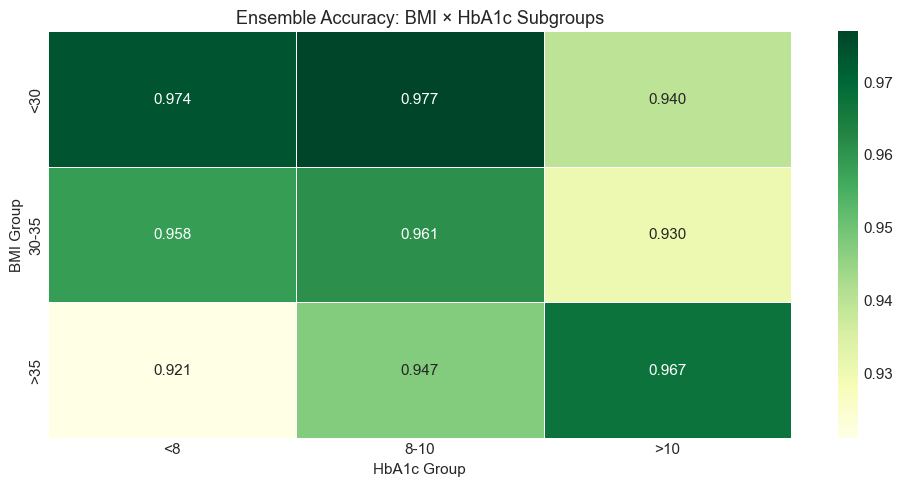

In [32]:
if meta.get('cf_test') is not None:
    test_df = df.iloc[meta['test_idx']].copy()
    test_df['predicted_action'] = ens_greedy
    test_df['correct'] = (ens_greedy == meta['opt_test'])

    # By BMI group
    test_df['bmi_group'] = pd.cut(test_df['bmi'], bins=[0, 30, 35, 100], labels=['<30', '30-35', '>35'])

    print("Ensemble accuracy by BMI group:")
    for g in ['<30', '30-35', '>35']:
        mask = test_df['bmi_group'] == g
        acc = test_df.loc[mask, 'correct'].mean()
        n_g = mask.sum()
        print(f"  BMI {g:<8} accuracy={acc:.4f}  n={n_g}")

    # By HbA1c severity
    test_df['hba1c_group'] = pd.cut(test_df['hba1c_baseline'],
                                     bins=[0, 8, 10, 100], labels=['<8', '8-10', '>10'])
    print("\nEnsemble accuracy by HbA1c group:")
    for g in ['<8', '8-10', '>10']:
        mask = test_df['hba1c_group'] == g
        acc = test_df.loc[mask, 'correct'].mean()
        n_g = mask.sum()
        print(f"  HbA1c {g:<8} accuracy={acc:.4f}  n={n_g}")

    # By CVD status
    print("\nEnsemble accuracy by CVD status:")
    for cvd_val in [0, 1]:
        mask = test_df['cvd'] == cvd_val
        acc = test_df.loc[mask, 'correct'].mean()
        n_g = mask.sum()
        label = "CVD" if cvd_val == 1 else "No CVD"
        print(f"  {label:<12} accuracy={acc:.4f}  n={n_g}")

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 5))
    subgroup_acc = test_df.groupby(['bmi_group', 'hba1c_group'])['correct'].mean().unstack()
    sns.heatmap(subgroup_acc, annot=True, fmt='.3f', cmap='YlGn', ax=ax, linewidths=0.5)
    ax.set_title("Ensemble Accuracy: BMI × HbA1c Subgroups")
    ax.set_ylabel("BMI Group")
    ax.set_xlabel("HbA1c Group")
    plt.tight_layout()
    plt.show()


## Save Best Model

In [33]:
ensemble.save("../models/reward_model")
print("Ensemble model saved to ../models/reward_model/")

# Save evaluation results
save_results({
    "ensemble_eval": eval_results,
    "depth_sweep": depth_df.to_dict(orient='records'),
    "nest_sweep": nest_df.to_dict(orient='records'),
}, path="../results/reward_model_results.json")
print("Results saved to ../results/reward_model_results.json")


Ensemble model saved to ../models/reward_model/
Results saved to ../results/reward_model_results.json


## Summary

In [34]:
print("=" * 60)
print("REWARD MODEL SUMMARY")
print("=" * 60)
print(f"\n  Best model:        Ensemble (5 XGBoost)")
print(f"  Overall RMSE:      {eval_results['overall_rmse']:.4f}")
if 'policy_accuracy' in eval_results:
    print(f"  Policy accuracy:   {eval_results['policy_accuracy']:.4f} ({eval_results['policy_accuracy']*100:.1f}%)")
if 'policy_value' in eval_results:
    print(f"  Policy value:      {eval_results['policy_value']:.4f}")
if 'oracle_value' in eval_results:
    print(f"  Oracle value:      {eval_results['oracle_value']:.4f}")
if 'regret' in eval_results:
    print(f"  Regret:            {eval_results['regret']:.4f}")
print(f"\n  Model saved:       ../models/reward_model/")
print("=" * 60)

REWARD MODEL SUMMARY

  Best model:        Ensemble (5 XGBoost)
  Overall RMSE:      0.4107
  Policy accuracy:   0.9535 (95.3%)
  Policy value:      6.0242
  Oracle value:      6.0344
  Regret:            0.0102

  Model saved:       ../models/reward_model/
